In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import math as m
from turnpike import solve_turnpike

# 1-Qubit case

In [2]:
class LSZ_experiment():

    def __init__(self, n_qubits, epsilon, H_target_dictionary, ramp_time, wait_time):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.n_qubits = n_qubits
        self.e = epsilon
        self.Ht_dict = H_target_dictionary

        self.to =  0
        self.tw = wait_time
        self.tr = ramp_time
        
        self.tf = 2*self.tr + self.tw
       
        self.slope = 1/self.tr

        self.npsx, self.npsy, self.npsz = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]]), np.array([[1, 0], [0, -1]])
        self.qtsx, self.qtsy, self.qtsz = qt.sigmax(), qt.sigmay(), qt.sigmaz() 

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)


        self.qtsx_list, self.qtsy_list, self.qtsz_list = self.initialize_qt_operators()
        self.npsx_list, self.npsy_list, self.npsz_list = self.initialize_np_operators()

        self.H0_numpy = self.build_H0_numpy()
        self.H0_qutip = self.build_H0_qutip()

        self.Ht_numpy = self.build_Ht_numpy()
        self.Ht_qutip = self.build_Ht_qutip()

    
    def kron_n(self, ops):
        '''Tensor product of a list of operators'''
        out = ops[0]
        for A in ops[1:]:
            out = np.kron(out, A)
        return out
    
    def build_H0_numpy(self):
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        for i in range(self.n_qubits):
            H += -self.e*self.npsx_list[i]
        return H

    def build_H0_qutip(self):
        H = 0
        for i in range(self.n_qubits):
            H += -self.e*self.qtsx_list[i]
        return H
    
    def build_Ht_numpy(self):
        #Initialize Hamiltonian
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.npsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs 
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.npsz_list[i] @ self.npsz_list[j]
                    k += 1

        return H

    def build_Ht_qutip(self):
        #Initialize Hamiltonian
        H = 0
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.qtsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.qtsz_list[i] * self.qtsz_list[j]
                    k += 1

        return H

    def initialize_np_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.npsx, self.npsy, self.npsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [np.eye(2) for _ in range(self.n_qubits)]
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(self.kron_n(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(self.kron_n(op_list))
            op_list[i] = sz
            sz_list.append(self.kron_n(op_list))

        return sx_list, sy_list, sz_list

    def initialize_qt_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.qtsx, self.qtsy, self.qtsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [qt.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(qt.tensor(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(qt.tensor(op_list))
            op_list[i] = sz
            sz_list.append(qt.tensor(op_list))

        return sx_list, sy_list, sz_list


    def trapezoid_s(self, t):
        return np.minimum(1, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        s = self.trapezoid_s(t)
        return (1-s)*self.H0_numpy + s*self.Ht_numpy
    
    def H_qutip(self):

        H = [[self.H0_qutip, lambda t, args: 1 - self.trapezoid_s(t)], [self.Ht_qutip, lambda t, args: self.trapezoid_s(t)]]

        return H
    
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    

    def time_evolution(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)

        #Prepare ground state of H at time 0
        psi0 = qt.tensor([1/np.sqrt(2)*(self.ket0 + self.ket1)]*self.n_qubits)

        #Initialize qutip Hamiltonian
        H = self.H_qutip()

        #Time evolution
        return qt.sesolve(H, psi0, t_list)
    
    def calculate_populations(self, sim_res):

        final_state = sim_res.states[-1].full().flatten()

        H_f = self.H_numpy(self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        # eigvecs_f columns are eigenvectors; eigvecs_f[:, k] is the k-th eigenvector
        n_states = 2**self.n_qubits
        populations = np.zeros(n_states)
        for k in range(n_states):
            overlap = np.dot(eigvecs_f[:, k].conj(), final_state)
            populations[k] = np.real(overlap * overlap.conj())

        return populations



- Ramp time controls the speed that we use to bring the system to the middle point. The faster, the higher the transition probability.

- High ramp time makes oscillations larger

- for LZ we ramp and pass the crossing once. For LZS you cross the gap twice. during wait time, s=1, no transverse term. Start at Hx, both terms evolve.

In [3]:
epsilon = 3
alpha = 0.5
ramp_time = 0.5
n_steps = 201

#1 qubit example
# local_z_list = np.array([1])
# zz_terms = np.array([])

#2 qubit example
local_z_list = np.array([1.1,2.34])
zz_terms = np.array([0.55])

#3 qubit example
# local_z_list = np.array([2, 3, 1.5])
# zz_terms = np.array([1, 0.5, 1.25])

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)
pc_list = []
pe_list = []


H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

wait_test = 0
test =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_test)

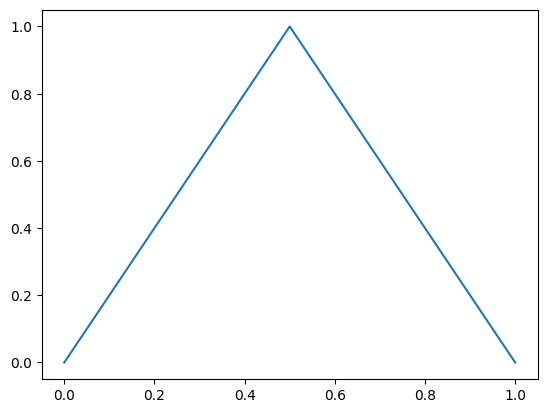

In [4]:
t_list, s_list = test.show_schedule(n_steps)
plt.plot(t_list, s_list)

[-2.89 -1.79  0.69  3.99]


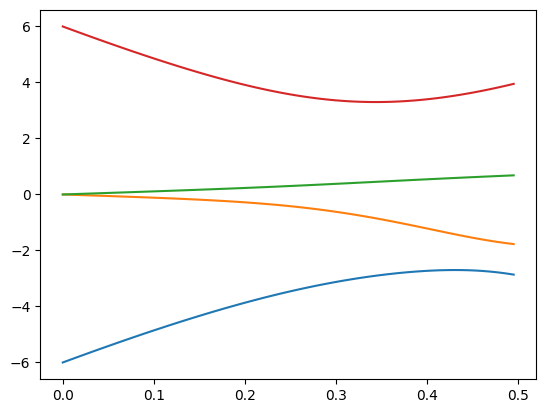

In [5]:
t_list, egvals, egvecs = test.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])

print(egvals[midpoint])

In [6]:
for wait_time in tw_l:
    experiment =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_time)

    result = experiment.time_evolution(n_steps)

    populations = experiment.calculate_populations(result)

    pc_list.append(np.real(populations[0]))

## Next steps:

0. Fixed code to do the right thing --DONE

1. Extract frequency and epsilon from oscillations --DONE

2. Test for 2 qubit system. Modify class to take in number of qubits external target Hamiltonian --DONE

3. Test interferometry for 2, 3 qubit systems --DONE

4. Look at ordering of energies, like how Matthias does it

4.1. Solve turnpike problem

4.2. Extract phases from Fourier analysis

In [7]:
def fourier_analysis(pc_list, tw_l, n_peaks=15, prominence_threshold=0.05):
    """
    Fourier analysis extracting all significant frequencies.
    
    Parameters
    ----------
    pc_list : array-like
        Signal (e.g. ground state population over time).
    tw_l : array-like
        Time axis.
    n_peaks : int
        Maximum number of peaks to return.
    prominence_threshold : float
        Peaks below this fraction of the dominant peak magnitude are ignored.
    
    Returns
    -------
    freqs_peaks : np.ndarray
        Frequencies of the identified peaks, sorted by magnitude (descending).
    amplitudes : np.ndarray
        Corresponding amplitudes.
    """
    from scipy.signal import find_peaks

    y = np.array(pc_list)
    t = np.array(tw_l)
    
    N = len(y)
    dt = t[1] - t[0]
    
    # FFT over positive frequencies only (skip DC at index 0)
    spectrum = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, dt)
    magnitude = np.abs(spectrum)
    
    pos_idx = np.where(freqs > 0)[0]
    pos_freqs = freqs[pos_idx]
    pos_mag = magnitude[pos_idx]
    
    # Find all local peaks — low distance/prominence to avoid missing broad peaks
    peak_locs, _ = find_peaks(pos_mag, distance=1, prominence=0.01 * pos_mag.max())
    if len(peak_locs) == 0:
        peak_locs = np.array([np.argmax(pos_mag)])
    
    # Filter by prominence relative to the dominant peak
    threshold = prominence_threshold * pos_mag[peak_locs].max()
    peak_locs = peak_locs[pos_mag[peak_locs] >= threshold]
    
    # Sort by magnitude descending and take top n_peaks
    order = np.argsort(pos_mag[peak_locs])[::-1]
    peak_locs = peak_locs[order[:n_peaks]]
    
    freqs_peaks = pos_freqs[peak_locs]
    amplitudes = 2 * pos_mag[peak_locs] / N

    # x-axis: crop just past the highest detected frequency
    x_max = freqs_peaks.max() * 1.15

    # --- Plots ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, y, 'b-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Signal')
    plt.title('Original Signal')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(pos_freqs, pos_mag, 'r-', linewidth=1.5)
    colors = plt.cm.tab10.colors
    for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
        plt.axvline(f, color=colors[i % len(colors)], linestyle='--',
                    label=f'f{i+1}={f:.4f}, A={a:.4f}')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, x_max)
    plt.title('Fourier Transform')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Identified frequencies:")
    for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
        print(f"  f{i+1} = {f:.6f},  amplitude = {a:.6f}")
    
    return freqs_peaks, amplitudes


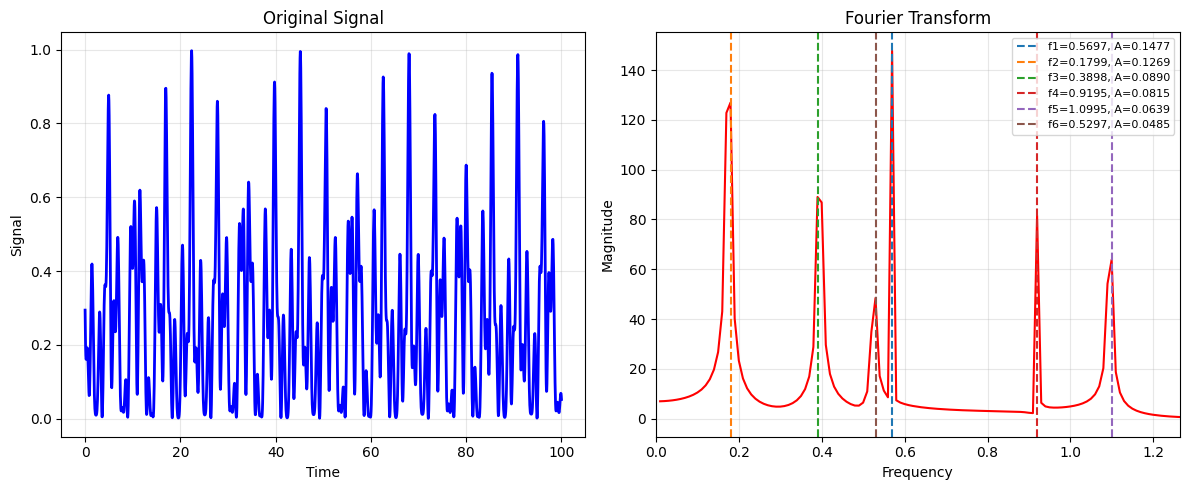

Identified frequencies:
  f1 = 0.569715,  amplitude = 0.147745
  f2 = 0.179910,  amplitude = 0.126940
  f3 = 0.389805,  amplitude = 0.089027
  f4 = 0.919540,  amplitude = 0.081544
  f5 = 1.099450,  amplitude = 0.063862
  f6 = 0.529735,  amplitude = 0.048461


In [8]:
freqs_peaks, amplitudes = fourier_analysis(pc_list, tw_l, n_peaks = m.factorial(2**nqubits -1))

In [9]:
e_differences = []
for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
    print(f"f{i+1}: period = {1/f:.6f},  recovered alpha = {2*np.pi*f:.6f}  (amplitude = {a:.6f})")
    e_differences.append(2*np.pi*f)


print(egvals[midpoint])


f1: period = 1.755264,  recovered alpha = 3.579625  (amplitude = 0.147745)
f2: period = 5.558335,  recovered alpha = 1.130408  (amplitude = 0.126940)
f3: period = 2.565385,  recovered alpha = 2.449217  (amplitude = 0.089027)
f4: period = 1.087500,  recovered alpha = 5.777640  (amplitude = 0.081544)
f5: period = 0.909546,  recovered alpha = 6.908048  (amplitude = 0.063862)
f6: period = 1.887736,  recovered alpha = 3.328423  (amplitude = 0.048461)
[-2.89 -1.79  0.69  3.99]


In [10]:
solutions = solve_turnpike(e_differences)

Reconstructing 4 energy levels from 6 pairwise differences.



In [11]:
print(solutions)

[0.         1.13040787 3.57962492 6.90804809]


In [35]:
real_vals = egvals[midpoint]
shifted_vals = [i - real_vals[0] for i in real_vals]
print('  '.join(f'{v:.3f}' for v in shifted_vals))

0.000  1.100  3.580  6.880


-1.7899999999999998
